In [44]:
import numpy as np
import pandas as pd
from pathlib import Path
from natsort import natsorted
import matplotlib.pyplot as plt
import h5py
plt.style.use('./graph_preset.mplstyle')

### １．データの読み込み

In [45]:
run_dir = Path("../runs")
read_paths = natsorted(run_dir.glob("*.h5"))

for idx, read_path in enumerate(read_paths, start=0):
    run_name = Path(read_path).name   # e.g. 250526105004.h5
    print(f"{idx}: {run_name}")

0: 260615141244.h5
1: 260615141309.h5
2: 260615142021.h5
3: 260619203323.h5
4: 260619211531.h5
5: 260619211615.h5
6: 260619211701.h5
7: 260619211733.h5


### ２．データの選択

In [46]:
index = 5

with h5py.File(read_paths[index], "r") as f: # read_paths[#] that you want to read
    print(f"--- Structure of {read_path} ---")

    def print_structure(name, obj):
        # データセットの場合は形状とデータ型も表示
        if isinstance(obj, h5py.Dataset):
            print(f"  {name} (Dataset) | Shape: {obj.shape}, Dtype: {obj.dtype}")
        # グループの場合はグループ名を表示
        elif isinstance(obj, h5py.Group):
            print(f"  {name} (Group)")

    f.visititems(print_structure)
    print("---------------------------------")

df_data = dict()

def store_dataset(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"  Loading: {name} | Shape: {obj.shape}")
        df = pd.DataFrame(obj[:])
        df_data[name] = df

with h5py.File(read_paths[index], "r") as f:
    print(f"--- Loading all datasets from {read_paths[index]} ---")
    f.visititems(store_dataset)
    print("---------------------------------------------")

print("\n--- Dictionary Keys ---")
print(list(df_data.keys()))
print("-----------------------")

if 'logs/log' in df_data:
    df_data['logs/log'].columns = ["rel_time", "com", "vel", "Iu", "Vu", "Iv", "Vv", "Iw", "Vw", "Ptot_sum",]

for name in list(df_data.keys())[:-1]:
    if name in df_data:
        df_data[name].columns = ["rel_time", "Iu", "Vu", "Ptot_sum", "Ptot_w"]

--- Structure of ..\runs\260619211733.h5 ---
  current_reduction (Group)
  logs (Group)
  logs/log (Dataset) | Shape: (12371, 10), Dtype: float32
---------------------------------
--- Loading all datasets from ..\runs\260619211615.h5 ---
  Loading: logs/log | Shape: (12371, 10)
---------------------------------------------

--- Dictionary Keys ---
['logs/log']
-----------------------


In [47]:
dfs = dict()
dfs["normal"] = df_data

In [48]:
index = 6

with h5py.File(read_paths[index], "r") as f: # read_paths[#] that you want to read
    print(f"--- Structure of {read_path} ---")

    def print_structure(name, obj):
        # データセットの場合は形状とデータ型も表示
        if isinstance(obj, h5py.Dataset):
            print(f"  {name} (Dataset) | Shape: {obj.shape}, Dtype: {obj.dtype}")
        # グループの場合はグループ名を表示
        elif isinstance(obj, h5py.Group):
            print(f"  {name} (Group)")

    f.visititems(print_structure)
    print("---------------------------------")

df_data = dict()

def store_dataset(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"  Loading: {name} | Shape: {obj.shape}")
        df = pd.DataFrame(obj[:])
        df_data[name] = df

with h5py.File(read_paths[index], "r") as f:
    print(f"--- Loading all datasets from {read_paths[index]} ---")
    f.visititems(store_dataset)
    print("---------------------------------------------")

print("\n--- Dictionary Keys ---")
print(list(df_data.keys()))
print("-----------------------")

if 'logs/log' in df_data:
    df_data['logs/log'].columns = ["rel_time", "com", "vel", "Iu", "Vu", "Iv", "Vv", "Iw", "Vw", "Ptot_sum",]

for name in list(df_data.keys())[:-1]:
    if name in df_data:
        df_data[name].columns = ["rel_time", "Iu", "Vu", "Ptot_sum", "Ptot_w"]

dfs["offset_IV"] = df_data

--- Structure of ..\runs\260619211733.h5 ---
  current_reduction (Group)
  logs (Group)
  logs/log (Dataset) | Shape: (17792, 10), Dtype: float32
---------------------------------
--- Loading all datasets from ..\runs\260619211701.h5 ---
  Loading: logs/log | Shape: (17792, 10)
---------------------------------------------

--- Dictionary Keys ---
['logs/log']
-----------------------


In [49]:
index = 7

with h5py.File(read_paths[index], "r") as f: # read_paths[#] that you want to read
    print(f"--- Structure of {read_path} ---")

    def print_structure(name, obj):
        # データセットの場合は形状とデータ型も表示
        if isinstance(obj, h5py.Dataset):
            print(f"  {name} (Dataset) | Shape: {obj.shape}, Dtype: {obj.dtype}")
        # グループの場合はグループ名を表示
        elif isinstance(obj, h5py.Group):
            print(f"  {name} (Group)")

    f.visititems(print_structure)
    print("---------------------------------")

df_data = dict()

def store_dataset(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"  Loading: {name} | Shape: {obj.shape}")
        df = pd.DataFrame(obj[:])
        df_data[name] = df

with h5py.File(read_paths[index], "r") as f:
    print(f"--- Loading all datasets from {read_paths[index]} ---")
    f.visititems(store_dataset)
    print("---------------------------------------------")

print("\n--- Dictionary Keys ---")
print(list(df_data.keys()))
print("-----------------------")

if 'logs/log' in df_data:
    df_data['logs/log'].columns = ["rel_time", "com", "vel", "Iu", "Vu", "Iv", "Vv", "Iw", "Vw", "Ptot_sum",]

for name in list(df_data.keys())[:-1]:
    if name in df_data:
        df_data[name].columns = ["rel_time", "Iu", "Vu", "Ptot_sum", "Ptot_w"]

dfs["offset_IV_minus"] = df_data

--- Structure of ..\runs\260619211733.h5 ---
  current_reduction (Group)
  logs (Group)
  logs/log (Dataset) | Shape: (17097, 10), Dtype: float32
---------------------------------
--- Loading all datasets from ..\runs\260619211733.h5 ---
  Loading: logs/log | Shape: (17097, 10)
---------------------------------------------

--- Dictionary Keys ---
['logs/log']
-----------------------


### ３．プロット

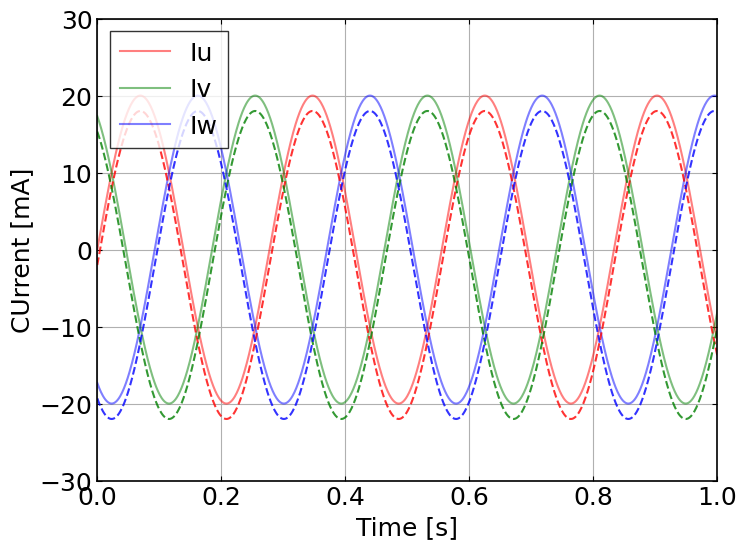

In [65]:
# Rot. Freq (Command, Measured)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(dfs["normal"]["logs/log"]["rel_time"], dfs["normal"]["logs/log"]["Iu"]*1000, label="Iu", color="r", alpha=0.5)
ax.plot(dfs["normal"]["logs/log"]["rel_time"], dfs["normal"]["logs/log"]["Iv"]*1000, label="Iv", color="g", alpha=0.5)
ax.plot(dfs["normal"]["logs/log"]["rel_time"], dfs["normal"]["logs/log"]["Iw"]*1000, label="Iw", color="b", alpha=0.5)

#ax.plot(dfs["offset_IV"]["logs/log"]["rel_time"], dfs["offset_IV"]["logs/log"]["Iu"]*1000, color="r", alpha=0.8)
#ax.plot(dfs["offset_IV"]["logs/log"]["rel_time"], dfs["offset_IV"]["logs/log"]["Iv"]*1000, color="g", alpha=0.8)
#ax.plot(dfs["offset_IV"]["logs/log"]["rel_time"], dfs["offset_IV"]["logs/log"]["Iw"]*1000, color="b", alpha=0.8)
ax.plot(dfs["offset_IV_minus"]["logs/log"]["rel_time"], dfs["offset_IV_minus"]["logs/log"]["Iu"]*1000, color="r", alpha=0.8, linestyle="--")
ax.plot(dfs["offset_IV_minus"]["logs/log"]["rel_time"], dfs["offset_IV_minus"]["logs/log"]["Iv"]*1000, color="g", alpha=0.8, linestyle="--")
ax.plot(dfs["offset_IV_minus"]["logs/log"]["rel_time"], dfs["offset_IV_minus"]["logs/log"]["Iw"]*1000, color="b", alpha=0.8, linestyle="--")

ax.set_ylim(-30, 30)
ax.set_xlabel("Time [s]")
ax.set_ylabel("CUrrent [mA]")
ax.set_xlim(0, 1)

ax.grid()
ax.legend()

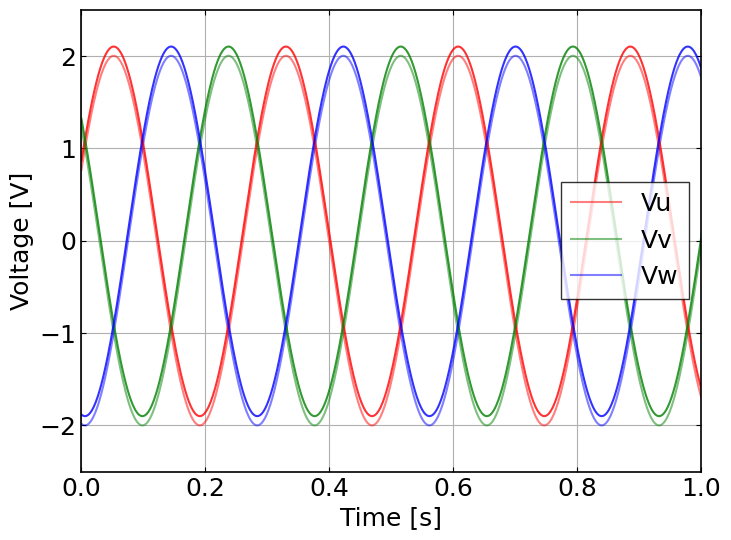

In [51]:
# Rot. Freq (Command, Measured)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(dfs["normal"]["logs/log"]["rel_time"], dfs["normal"]["logs/log"]["Vu"], label="Vu", color="r", alpha=0.5)
ax.plot(dfs["normal"]["logs/log"]["rel_time"], dfs["normal"]["logs/log"]["Vv"], label="Vv", color="g", alpha=0.5)
ax.plot(dfs["normal"]["logs/log"]["rel_time"], dfs["normal"]["logs/log"]["Vw"], label="Vw", color="b", alpha=0.5)

ax.plot(dfs["offset_IV"]["logs/log"]["rel_time"], dfs["offset_IV"]["logs/log"]["Vu"], color="r", alpha=0.8)
ax.plot(dfs["offset_IV"]["logs/log"]["rel_time"], dfs["offset_IV"]["logs/log"]["Vv"], color="g", alpha=0.8)
ax.plot(dfs["offset_IV"]["logs/log"]["rel_time"], dfs["offset_IV"]["logs/log"]["Vw"], color="b", alpha=0.8)

ax.set_ylim(-2.5, 2.5)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Voltage [V]")
ax.set_xlim(0, 1)

ax.grid()
ax.legend()

-0.032471749577866686


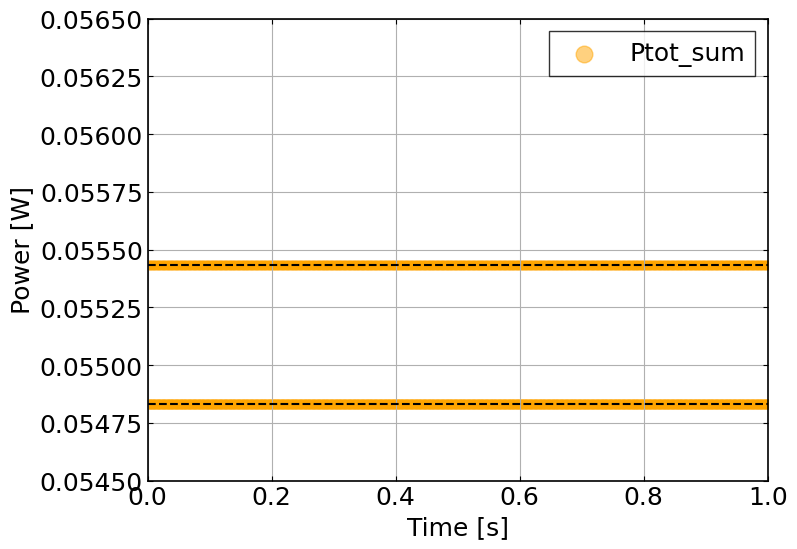

In [73]:

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(dfs["normal"]["logs/log"]["rel_time"], dfs["normal"]["logs/log"]["Ptot_sum"], label="Ptot_sum", color="orange", alpha=0.5)

#ax.scatter(dfs["offset_IV"]["logs/log"]["rel_time"], dfs["offset_IV"]["logs/log"]["Ptot_sum"], color="orange", alpha=0.8)

ax.scatter(dfs["offset_IV_minus"]["logs/log"]["rel_time"], dfs["offset_IV_minus"]["logs/log"]["Ptot_sum"], color="orange", alpha=0.8)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Power [W]")
ax.set_xlim(0, 1)
ax.set_ylim(0.05450, 0.05650)


ax.axhline(3*0.0184776, color="k", linestyle="--", alpha=1)
#ax.axhline(3*0.0186776, color="k", linestyle="--", alpha=1)
ax.axhline(3*0.0182776, color="k", linestyle="--", alpha=1)
print((3*0.0184776-3*0.0186776)/0.0184776)
ax.grid()
ax.legend()